### Задание
1. Обучите word-level RNN language model на собственном тексте Джейн Остин.
2. Постройте график training loss.
3. Сгенерируйте тексты:
   - greedy
   - sampling
   - sampling with temperature
   - sampling with top-k
4. Сравните качество генерации.
5. (Опционально) замените RNN на LSTM и сравните результаты.

## Скачать текст Мэнсфилд-парк Джейн Остин

In [59]:
import requests

In [60]:
GGDRIVE_URL = "https://drive.google.com/file/d/1A-JjKbo3koy3ARt8SgkmWtAVgYneF2Of/view?usp=drive_link"

In [61]:
def download_ggdrive_text(ggdrive_url: str) -> str:
    """
    Tải file text từ Google Drive public link
    """
    # Extract file ID
    file_id = ggdrive_url.split('/d/')[1].split('/')[0]

    # Google Drive download URL
    download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

    # Tải file
    session = requests.Session()
    response = session.get(download_url, stream=True)

    # Xử lý confirmation page nếu file lớn
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            params = {'id': file_id, 'confirm': value}
            response = session.get(download_url, params=params, stream=True)
            break

    return response.text

content = download_ggdrive_text(GGDRIVE_URL)

In [62]:
content = download_ggdrive_text(GGDRIVE_URL)
print(content[:500]+'\n')

Джейн Остин

Мэнсфилд-парк



ЧАСТЬ ПЕРВАЯ



Глава 1

Лет тому тридцать мисс Марии Уорд из Хантингдона, имевшей всего семь тысяч фунтов, посчастливилось пленить сэра Томаса Бертрама из Мэнсфилд-парка, что в графстве Нортгемптоншир, и таким образом возвыситься до положения жены баронета, владелицы прекрасного дома и значительного дохода со всеми вытекающими отсюда удобствами и возможностями. Весь Хантингдон пришел в восторг от столь замечательной партии, а ее дядя, адвокат, к тому же



In [63]:
import re
import math
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


0Б) Подготовим токины, НЕ используем лемматизацию или стемминг, НЕ удаляем стоп-слова

In [64]:
TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:'[А-Яа-яЁё]+)?")
def tokenize(text):
    text = text.lower()
    tokens = re.findall(TOKEN_RE, text)
    return tokens


In [65]:
tokens = tokenize(content)
print(tokens[:50])
print("Number of tokens:", len(tokens))
print("Number of unique raw tokens:", len(set(tokens)))

['джейн', 'остин', 'мэнсфилд', 'парк', 'часть', 'первая', 'глава', 'лет', 'тому', 'тридцать', 'мисс', 'марии', 'уорд', 'из', 'хантингдона', 'имевшей', 'всего', 'семь', 'тысяч', 'фунтов', 'посчастливилось', 'пленить', 'сэра', 'томаса', 'бертрама', 'из', 'мэнсфилд', 'парка', 'что', 'в', 'графстве', 'нортгемптоншир', 'и', 'таким', 'образом', 'возвыситься', 'до', 'положения', 'жены', 'баронета', 'владелицы', 'прекрасного', 'дома', 'и', 'значительного', 'дохода', 'со', 'всеми', 'вытекающими', 'отсюда']
Number of tokens: 139100
Number of unique raw tokens: 20156


## Тест 1

In [66]:
MAX_TOKENS = 500_000     # можно увеличить до 100_000 или больше
MAX_VOCAB = 10000

tokens = tokens[:MAX_TOKENS]
print("Using tokens:", len(tokens))

counter = Counter(tokens)
most_common = counter.most_common(MAX_VOCAB - 2)  # reserving <pad>, <unk>

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

def encode_token(tok):
    return stoi.get(tok, UNK_ID)

ids = [encode_token(tok) for tok in tokens]

print("Vocab size:", len(itos))
print("First 30 ids:", ids[:30])

Using tokens: 139100
Vocab size: 10000
First 30 ids: [8712, 8713, 162, 457, 503, 904, 310, 280, 160, 3165, 39, 396, 3166, 34, 8714, 5506, 79, 1280, 1940, 1024, 3985, 8715, 213, 231, 905, 34, 162, 636, 5, 4]


In [67]:
SEQ_LEN = 30
TRAIN_FRAC = 0.9
BATCH_SIZE = 32

class LanguageModelingDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx: idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx + 1: idx + self.seq_len + 1], dtype=torch.long)
        return x, y

split_idx = int(len(ids) * TRAIN_FRAC)
train_ids = ids[:split_idx]
test_ids = ids[split_idx:]

train_dataset = LanguageModelingDataset(train_ids, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_ids, SEQ_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("Train tokens:", len(train_ids))
print("Test tokens:", len(test_ids))
print("Train examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

xb, yb = next(iter(train_loader))
print("xb shape:", xb.shape)
print("yb shape:", yb.shape)

Train tokens: 125190
Test tokens: 13910
Train examples: 125160
Test examples: 13880
xb shape: torch.Size([32, 30])
yb shape: torch.Size([32, 30])


## Shapes in the model

- input ids: `(batch_size, seq_len)`
- embeddings: `(batch_size, seq_len, emb_dim)`
- RNN hidden states: `(batch_size, seq_len, hidden_dim)`
- output logits: `(batch_size, seq_len, vocab_size)`

На каждом шаге модель предсказывает распределение по всему словарю.

In [68]:
class WordRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        # x: (B, L)
        x = self.emb(x)          # (B, L, E)
        h, h_n = self.rnn(x, h0) # h: (B, L, H)
        logits = self.out(h)     # (B, L, V)
        return logits, h_n

In [69]:
VOCAB_SIZE = len(itos)
EMB_DIM = 64
HIDDEN_DIM = 128

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(10000, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=10000, bias=True)
)

In [70]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [71]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("logits shape:", logits.shape)  # (B, L, V)
#print("h_n shape:", h_n.shape)        # (1, B, H)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

logits shape: torch.Size([32, 30, 10000])
loss: 9.259285926818848


In [72]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
        f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
    )

Epoch 1/10 | train loss = 5.1804 | train ppl = 177.75 | test loss = 6.8243 | test ppl = 919.95
Epoch 2/10 | train loss = 3.1928 | train ppl = 24.36 | test loss = 7.8159 | test ppl = 2479.76
Epoch 3/10 | train loss = 2.4409 | train ppl = 11.48 | test loss = 8.6335 | test ppl = 5616.68
Epoch 4/10 | train loss = 2.0944 | train ppl = 8.12 | test loss = 9.2798 | test ppl = 10719.39
Epoch 5/10 | train loss = 1.9016 | train ppl = 6.70 | test loss = 9.7891 | test ppl = 17837.54
Epoch 6/10 | train loss = 1.7789 | train ppl = 5.92 | test loss = 10.2021 | test ppl = 26958.42
Epoch 7/10 | train loss = 1.6928 | train ppl = 5.43 | test loss = 10.5613 | test ppl = 38609.78
Epoch 8/10 | train loss = 1.6276 | train ppl = 5.09 | test loss = 10.8609 | test ppl = 52099.61
Epoch 9/10 | train loss = 1.5764 | train ppl = 4.84 | test loss = 11.1242 | test ppl = 67789.63
Epoch 10/10 | train loss = 1.5344 | train ppl = 4.64 | test loss = 11.3737 | test ppl = 87004.76


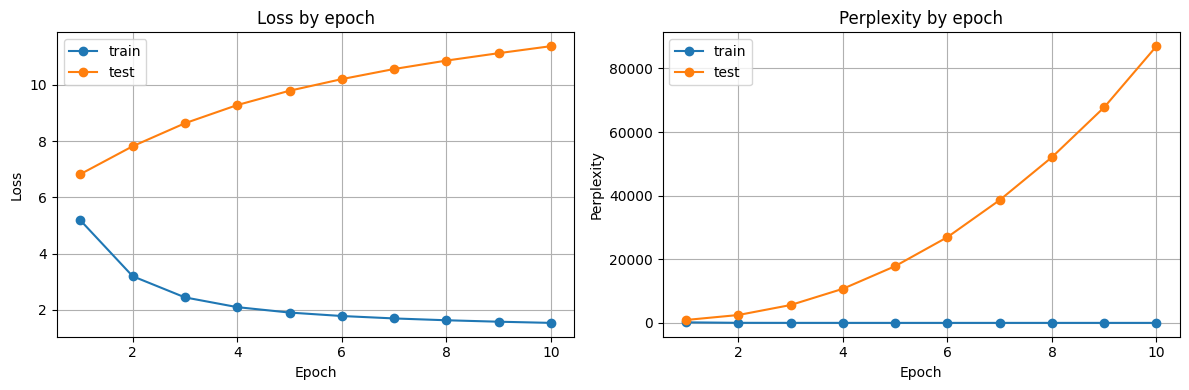

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [74]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    """
    logits: tensor of shape (V,)
    """
    logits = logits.detach().cpu()

    logits[UNK_ID] = -float('inf')

    if method == "greedy":
        return int(torch.argmax(logits).item())

    # temperature
    logits = logits / temperature

    # top-k
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())

    # plain sampling
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [75]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None
):
    model.eval()

    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization.")

    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]

    # Сначала прогоняем весь prompt, чтобы получить состояние
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    # Последний логит соответствует предсказанию после последнего токена prompt
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k
        )
        generated.append(next_id)

        # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated)

In [76]:
prompt = "В это время"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

в это время года и правда она не успела они вступили в танцевальную залу играли столь же что хотя в этой комнате быть может и вполне понять успел быть с анхельтом возможно ли за брата между какой или из пастората без сомнения соединят


In [77]:
prompt = "На другой день"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

на другой день если у тебя кузена эдмунда о многом и с тех пор как она намерена ясно рашуот мне ничего нельзя было поделать и в сердце молодые день об нем не могу быть тебе угодно но я и думал сделал что эта


In [78]:
prompt = "Она любит зиму"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

она любит зиму когда он снова отправится в плаванье и того эдмунд никогда не против созертона а какое девочка предстоит рашуот и следовало так прошли опять полились слезы и подумав прибавил как это не чересчур эту счастье все же уже самой подле себя


In [79]:
prompt = "Молодые люди с самого"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

молодые люди с самого начала понравились друг другу у эдмунда мисс крофорд как ты можешь выслушать вполовину долее него слушать но то была весьма разочарована вот вот придешь воспользовался вам вполне возможно вообразить и не узнать для нас хорошо но мне попался не эта


Вывод: Тест 1(EMB_DIM = 64, HIDDEN_DIM = 128) показывает, что после второй эпохи модель столкнулась с серьёзным переобучением: потери на обучающей выборке резко снизились (5,18 → 3,17), но потери на тестовой выборке резко возросли (6,81 → 7,81), а перплексия увеличилась примерно в 2,7 раза.

Три модели сгенерировали связные, грамматически правильные тексты, соответствующие стилю произведения.

Сгенерированный текст «На другой день» был в значительной степени случайным, с несколько неуклюжими предложениями, но всё же сохранил свой смысл.

## Тест 2

In [80]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(10000, 16)
  (rnn): RNN(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=10000, bias=True)
)

In [81]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [82]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("logits shape:", logits.shape)  # (B, L, V)
#print("h_n shape:", h_n.shape)        # (1, B, H)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

logits shape: torch.Size([32, 30, 10000])
loss: 9.258922576904297


In [51]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
        f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
    )

Epoch 1/10 | train loss = 6.7844 | train ppl = 883.94 | test loss = 6.6712 | test ppl = 789.32
Epoch 2/10 | train loss = 6.2620 | train ppl = 524.25 | test loss = 6.5293 | test ppl = 684.91
Epoch 3/10 | train loss = 5.8915 | train ppl = 361.97 | test loss = 6.5643 | test ppl = 709.29
Epoch 4/10 | train loss = 5.6509 | train ppl = 284.54 | test loss = 6.6550 | test ppl = 776.66
Epoch 5/10 | train loss = 5.4922 | train ppl = 242.79 | test loss = 6.7473 | test ppl = 851.72
Epoch 6/10 | train loss = 5.3858 | train ppl = 218.28 | test loss = 6.8378 | test ppl = 932.45
Epoch 7/10 | train loss = 5.3094 | train ppl = 202.22 | test loss = 6.9146 | test ppl = 1006.86
Epoch 8/10 | train loss = 5.2518 | train ppl = 190.92 | test loss = 6.9853 | test ppl = 1080.61
Epoch 9/10 | train loss = 5.2070 | train ppl = 182.55 | test loss = 7.0505 | test ppl = 1153.44
Epoch 10/10 | train loss = 5.1708 | train ppl = 176.06 | test loss = 7.1137 | test ppl = 1228.68


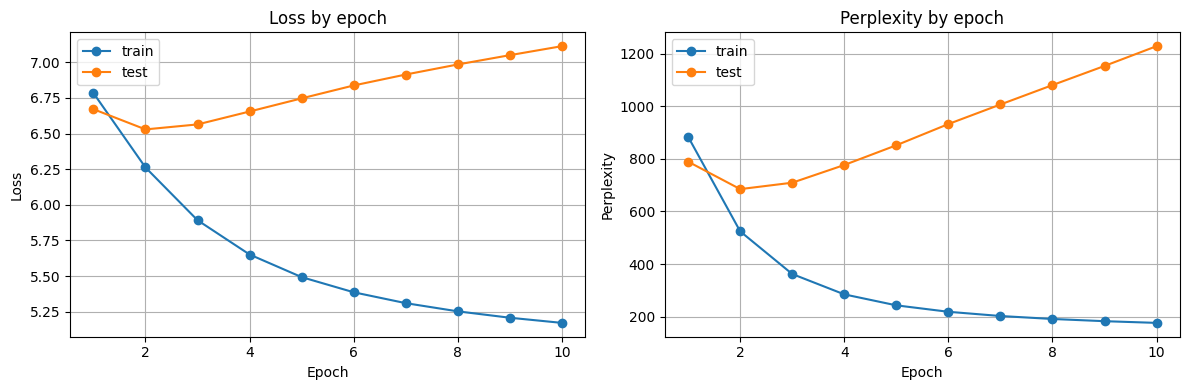

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    """
    logits: tensor of shape (V,)
    """
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    # temperature
    logits = logits / temperature

    # top-k
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())

    # plain sampling
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [54]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None
):
    model.eval()

    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization.")

    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]

    # Сначала прогоняем весь prompt, чтобы получить состояние
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    # Последний логит соответствует предсказанию после последнего токена prompt
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k
        )
        generated.append(next_id)

        # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated)

In [55]:
prompt = "В это время"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

в это время <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>


In [56]:
prompt = "На другой день"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

на другой день с поняли и <unk> жена крестьянина в голову помощи сердце только <unk> ему <unk> судьбы про генри и <unk> более джулии бертрам и были это уехал с ним <unk> а был даже тут изрядно подходящим любимую <unk> им такими <unk>


In [57]:
prompt = "Она любит зиму"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

она любит зиму союз молодая такой же этих их груди и вижу <unk> который равнодушия и по труда был остальное общество ничего <unk> всякий мальчик вид как не следовало что я так ли сильней из подобным манерам и довольно вот и мне довольно


In [58]:
prompt = "Молодые люди с самого"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

молодые люди с самого начала и не могла что нибудь <unk> <unk> и <unk> его и все равно и я думаю о том что фанни не <unk> но не в силах о ней что я не стану <unk> что я что я не не


Вывод: Тест 2(EMB_DIM = 16, HIDDEN_DIM = 16) показал, что недообучение модели было проблематичным: потери как на обучающей, так и на тестовой выборках уменьшались очень медленно, перплексия оставалась высокой (>170), а языковые структуры еще не были хорошо изучены.

Плохие результаты генерации текста:

- Появилось много бессмысленных токенов (unk).

- Предложения были неуклюжими, повторяющимися и лишенными связности.

- Подсказки "В это время" и "Молодые люди" почти исключительно генерировали бессмысленные токены (unk).

## Тест 3
EMB_DIM = 16

HIDDEN_DIM = 16

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Результат:

Epoch 1/10 | train loss = 7.5474 | train ppl = 1895.87 | test loss = 6.8456 | test ppl = 939.78

Epoch 2/10 | train loss = 6.8235 | train ppl = 919.24 | test loss = 6.8430 | test ppl = 937.29

Epoch 3/10 | train loss = 6.8111 | train ppl = 907.85 | test loss = 6.8661 | test ppl = 959.21

Epoch 4/10 | train loss = 6.7909 | train ppl = 889.71 | test loss = 6.8609 | test ppl = 954.25

Epoch 5/10 | train loss = 6.7357 | train ppl = 841.90 | test loss = 6.8285 | test ppl = 923.83

Epoch 6/10 | train loss = 6.6719 | train ppl = 789.89 | test loss = 6.8000 | test ppl = 897.82

Epoch 7/10 | train loss = 6.6120 | train ppl = 743.97 | test loss = 6.7704 | test ppl = 871.63

Epoch 8/10 | train loss = 6.5468 | train ppl = 696.98 | test loss = 6.7347 | test ppl = 841.13

Epoch 9/10 | train loss = 6.4725 | train ppl = 647.12 | test loss = 6.6970 | test ppl = 809.95

Epoch 10/10 | train loss = 6.3982 | train ppl = 600.79 | test loss = 6.6649 | test ppl = 784.37

## Тест 4
EMB_DIM = 32

HIDDEN_DIM = 64

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Результат:

Epoch 1/10 | train loss = 7.0373 | train ppl = 1138.29 | test loss = 6.8764 | test ppl = 969.12

Epoch 2/10 | train loss = 6.7571 | train ppl = 860.18 | test loss = 6.7659 | test ppl = 867.75

Epoch 3/10 | train loss = 6.5387 | train ppl = 691.38 | test loss = 6.6266 | test ppl = 754.94

Epoch 4/10 | train loss = 6.3043 | train ppl = 546.93 | test loss = 6.5463 | test ppl = 696.65

Epoch 5/10 | train loss = 6.0967 | train ppl = 444.41 | test loss = 6.5001 | test ppl = 665.22

Epoch 6/10 | train loss = 5.9121 | train ppl = 369.49 | test loss = 6.4736 | test ppl = 647.81

Epoch 7/10 | train loss = 5.7429 | train ppl = 311.95 | test loss = 6.4666 | test ppl = 643.28

Epoch 8/10 | train loss = 5.5865 | train ppl = 266.80 | test loss = 6.4704 | test ppl = 645.73

Epoch 9/10 | train loss = 5.4415 | train ppl = 230.78 | test loss = 6.4877 | test ppl = 656.98

Epoch 10/10 | train loss = 5.3065 | train ppl = 201.65 | test loss = 6.5117 | test ppl = 672.98

## Тест 5
EMB_DIM = 32

HIDDEN_DIM = 64

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

Результат:

Epoch 1/15 | train loss = 8.4222 | train ppl = 4546.73 | test loss = 7.4253 | test ppl = 1677.98

Epoch 2/15 | train loss = 7.1322 | train ppl = 1251.69 | test loss = 6.9514 | test ppl = 1044.60

Epoch 3/15 | train loss = 6.9233 | train ppl = 1015.65 | test loss = 6.9133 | test ppl = 1005.58

Epoch 4/15 | train loss = 6.8997 | train ppl = 991.98 | test loss = 6.9189 | test ppl = 1011.21

Epoch 5/15 | train loss = 6.8921 | train ppl = 984.46 | test loss = 6.9196 | test ppl = 1011.93

Epoch 6/15 | train loss = 6.8804 | train ppl = 973.04 | test loss = 6.9117 | test ppl = 1003.95

Epoch 7/15 | train loss = 6.8636 | train ppl = 956.84 | test loss = 6.9028 | test ppl = 995.07

Epoch 8/15 | train loss = 6.8489 | train ppl = 942.85 | test loss = 6.9070 | test ppl = 999.22

Epoch 9/15 | train loss = 6.8374 | train ppl = 932.08 | test loss = 6.9165 | test ppl = 1008.82

Epoch 10/15 | train loss = 6.8262 | train ppl = 921.71 | test loss = 6.9248 | test ppl = 1017.15

Epoch 11/15 | train loss = 6.8148 | train ppl = 911.23 | test loss = 6.9292 | test ppl = 1021.71

Epoch 12/15 | train loss = 6.8033 | train ppl = 900.82 | test loss = 6.9307 | test ppl = 1023.25

Epoch 13/15 | train loss = 6.7917 | train ppl = 890.41 | test loss = 6.9276 | test ppl = 1020.09

Epoch 14/15 | train loss = 6.7788 | train ppl = 879.01 | test loss = 6.9196 | test ppl = 1011.96

Epoch 15/15 | train loss = 6.7644 | train ppl = 866.44 | test loss = 6.9087 | test ppl = 1000.98

## Тест 6
EMB_DIM = 64

HIDDEN_DIM = 128

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Результат:

Epoch 1/15 | train loss = 6.9142 | train ppl = 1006.47 | test loss = 6.7760 | test ppl = 876.57

Epoch 2/15 | train loss = 6.4865 | train ppl = 656.21 | test loss = 6.5523 | test ppl = 700.88

Epoch 3/15 | train loss = 6.0969 | train ppl = 444.49 | test loss = 6.4518 | test ppl = 633.85

Epoch 4/15 | train loss = 5.7639 | train ppl = 318.60 | test loss = 6.4250 | test ppl = 617.11

Epoch 5/15 | train loss = 5.4642 | train ppl = 236.09 | test loss = 6.4304 | test ppl = 620.44

Epoch 6/15 | train loss = 5.1811 | train ppl = 177.87 | test loss = 6.4592 | test ppl = 638.54

Epoch 7/15 | train loss = 4.9131 | train ppl = 136.06 | test loss = 6.5106 | test ppl = 672.21

Epoch 8/15 | train loss = 4.6621 | train ppl = 105.86 | test loss = 6.5786 | test ppl = 719.51

Epoch 9/15 | train loss = 4.4310 | train ppl = 84.01 | test loss = 6.6601 | test ppl = 780.65

Epoch 10/15 | train loss = 4.2201 | train ppl = 68.04 | test loss = 6.7478 | test ppl = 852.21

Epoch 11/15 | train loss = 4.0286 | train ppl = 56.18 | test loss = 6.8383 | test ppl = 932.91

Epoch 12/15 | train loss = 3.8544 | train ppl = 47.20 | test loss = 6.9348 | test ppl = 1027.46

Epoch 13/15 | train loss = 3.6958 | train ppl = 40.28 | test loss = 7.0343 | test ppl = 1134.89

Epoch 14/15 | train loss = 3.5510 | train ppl = 34.85 | test loss = 7.1334 | test ppl = 1253.19

Epoch 15/15 | train loss = 3.4186 | train ppl = 30.53 | test loss = 7.2324 | test ppl = 1383.60

In [83]:
VOCAB_SIZE = len(itos)
EMB_DIM = 64
HIDDEN_DIM = 128

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(10000, 64)
  (rnn): RNN(64, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=10000, bias=True)
)

In [84]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [85]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("logits shape:", logits.shape)  # (B, L, V)
#print("h_n shape:", h_n.shape)        # (1, B, H)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

logits shape: torch.Size([32, 30, 10000])
loss: 9.244762420654297


In [86]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
        f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
    )

Epoch 1/10 | train loss = 6.9167 | train ppl = 1008.96 | test loss = 6.7744 | test ppl = 875.12
Epoch 2/10 | train loss = 6.5030 | train ppl = 667.13 | test loss = 6.5622 | test ppl = 707.85
Epoch 3/10 | train loss = 6.1284 | train ppl = 458.71 | test loss = 6.4465 | test ppl = 630.46
Epoch 4/10 | train loss = 5.7774 | train ppl = 322.93 | test loss = 6.4178 | test ppl = 612.65
Epoch 5/10 | train loss = 5.4508 | train ppl = 232.93 | test loss = 6.4295 | test ppl = 619.89
Epoch 6/10 | train loss = 5.1464 | train ppl = 171.82 | test loss = 6.4681 | test ppl = 644.29
Epoch 7/10 | train loss = 4.8657 | train ppl = 129.76 | test loss = 6.5266 | test ppl = 683.07
Epoch 8/10 | train loss = 4.6092 | train ppl = 100.41 | test loss = 6.5992 | test ppl = 734.51
Epoch 9/10 | train loss = 4.3770 | train ppl = 79.60 | test loss = 6.6840 | test ppl = 799.47
Epoch 10/10 | train loss = 4.1671 | train ppl = 64.53 | test loss = 6.7739 | test ppl = 874.68


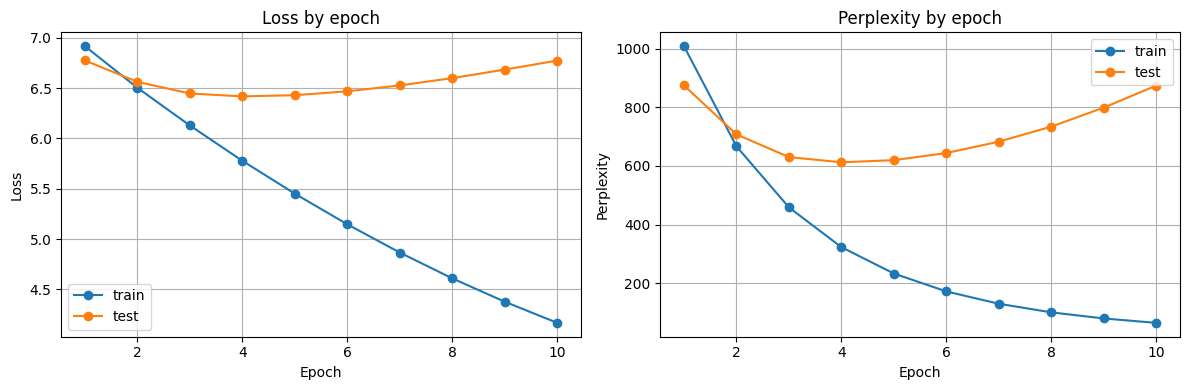

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [88]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    """
    logits: tensor of shape (V,)
    """
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    # temperature
    logits = logits / temperature

    # top-k
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())

    # plain sampling
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [89]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None
):
    model.eval()

    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization.")

    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]

    # Сначала прогоняем весь prompt, чтобы получить состояние
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    # Последний логит соответствует предсказанию после последнего токена prompt
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k
        )
        generated.append(next_id)

        # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated)

In [90]:
prompt = "В это время"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

в это время года назад в <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>


In [91]:
prompt = "На другой день"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

на другой день питал это без сомненья похвастать себе это я бы надеюсь ты живешь к вашему дальнейшим рассудительности с кем же <unk> вокруг она без сомненья существуют тебя строчки <unk> фанни еще фанни а едва участвовать <unk> ни вести чтобы передать сказать


In [92]:
prompt = "Она любит зиму"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

она любит зиму которые стала выезжать их имеет потом намеревался уже давным <unk> об нем почитая в пасторат где фанни сидела и думала когда она слушала и с живым восхищеньем после обаяние надобно малейшей сестре мисс андерсон так мне после того как ты


In [93]:
prompt = "Молодые люди с самого"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

молодые люди с самого начала на все это было бы рада в мэнсфилд и когда я думаю я думаю я могу судить по крайней <unk> в мэнсфилд парке причем в <unk> пору не <unk> <unk> я так что я тебя представлял не мог не


Вывод: Незначительное переобучение: потери на обучающей выборке неуклонно снижались (6,92 → 4,17), потери на тестовой выборке снижались до 4-й эпохи (6,77 → 6,42), затем постепенно увеличивались (6,42 → 6,77), перплексия на тестовой выборке увеличилась с 612 до 875.

Запрос "В это время": сгенерировано много <непонятных символов>, наихудшие результаты.

Запрос "На другой день": текст имеет структуру, но все еще содержит <непонятные символы>.

Запрос "На любит зиму": достаточно связный, мало <непонятных символов>, близок к стилю произведения.

Запрос "Молодые люди": повторяется слово "я думаю".

Тест 7 статистически лучший (наиболее стабильная ошибка), но качество генерации текста в нем хуже, чем в Тесте 1.

Тест 1 обеспечивает наилучшее качество генерации текста (связный текст, меньше неразборчивого текста, близкий к оригинальному стилю), но страдает от сильного переобучения.

Тесты 6 и 7 достигают наилучшего баланса между способностью к обучению и обобщению.

 Чем greedy decoding отличается от sampling?

Greedy всегда выбирает токен с максимальной вероятностью, sampling же случайно

 Как влияет temperature?

 Temperature влияет на гнерацию, чем меньше температура тем больше разнообразия вероятности

 Что меняется при top-k?

 Выбирает наиболее вероятные слова для генерации